In [1]:
import os
import joblib
import numpy as np
import pandas as pd

def load_encoded(sample_size=10000):
    paths = [
        "data/processed/encoded.pkl",
        "../data/processed/encoded.pkl",
        "../../data/processed/encoded.pkl"
    ]

    df = None
    for path in paths:
        if os.path.exists(path):
            print(f"✅ Loading from: {path}")
            df = joblib.load(path)
            break

    if df is None:
        raise FileNotFoundError(
            "encoded.pkl not found.\nRun: python src/preprocessing/encoding.py"
        )

    # 🔥 Memory safe
    df = df.sample(n=min(sample_size, len(df)), random_state=42)

    return df

def ensure_numpy(X):
    return X.values if hasattr(X, "values") else X

In [5]:
df = load_encoded(sample_size=8000)

target = "defects"

X = df.drop(columns=[target])
y = df[target]

print("Original Distribution:")
print(y.value_counts())

✅ Loading from: ../data/processed/encoded.pkl
Original Distribution:
defects
1    6765
0    1235
Name: count, dtype: int64


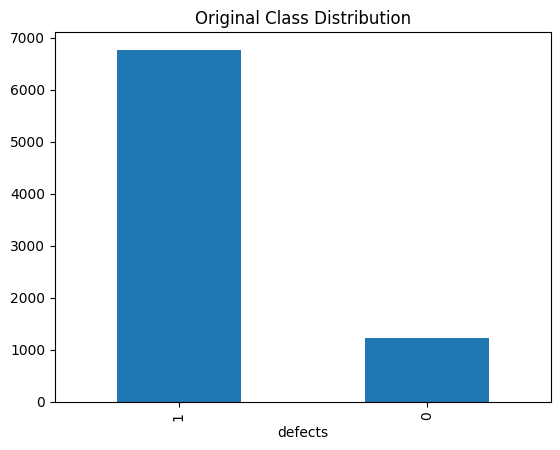

In [6]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Original Class Distribution")
plt.show()

After SMOTE:
defects
1    6765
0    6765
Name: count, dtype: int64


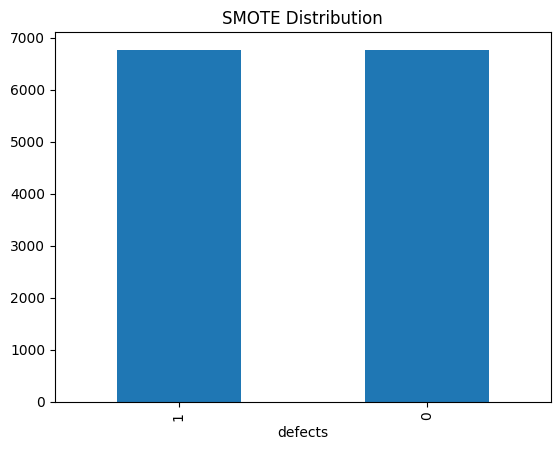

In [7]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X, y)

print("After SMOTE:")
print(pd.Series(y_sm).value_counts())

pd.Series(y_sm).value_counts().plot(kind="bar")
plt.title("SMOTE Distribution")
plt.show()

After ADASYN:
defects
0    6833
1    6765
Name: count, dtype: int64


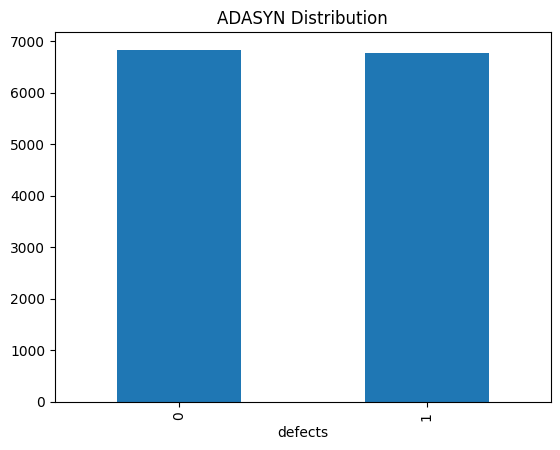

In [8]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(random_state=42)
X_ad, y_ad = adasyn.fit_resample(X, y)

print("After ADASYN:")
print(pd.Series(y_ad).value_counts())

pd.Series(y_ad).value_counts().plot(kind="bar")
plt.title("ADASYN Distribution")
plt.show()

In [9]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = dict(zip(classes, weights))

print("Class Weights:")
print(class_weights)

Class Weights:
{0: 3.2388663967611335, 1: 0.5912786400591279}


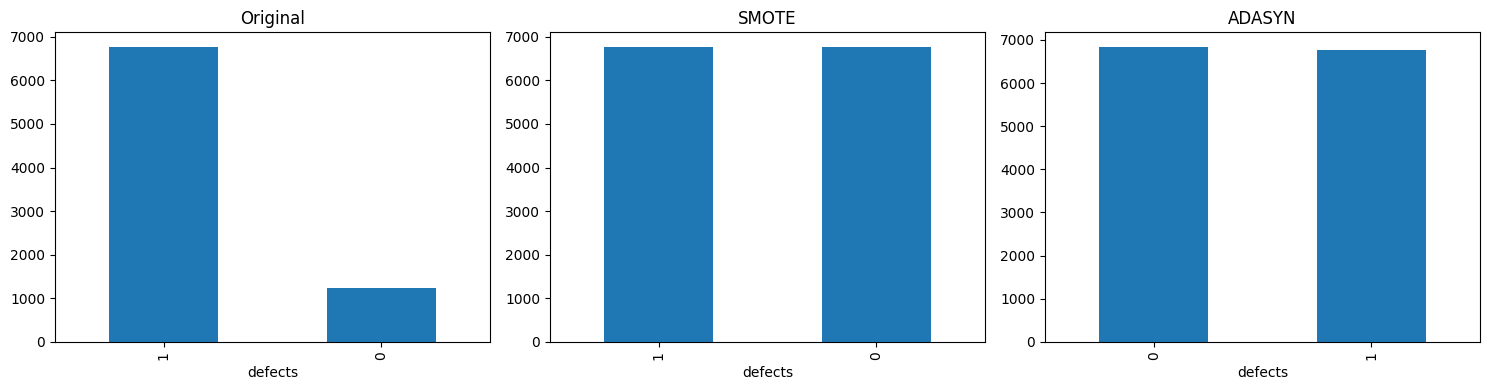

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

y.value_counts().plot(kind="bar", ax=axes[0], title="Original")
pd.Series(y_sm).value_counts().plot(kind="bar", ax=axes[1], title="SMOTE")
pd.Series(y_ad).value_counts().plot(kind="bar", ax=axes[2], title="ADASYN")

plt.tight_layout()
plt.show()